### Summary of the Notebook

This notebook processes and analyzes global air pollution data, combining it with city and country information, and performs various data cleaning, visualization, and machine learning tasks. Below is a summary of the steps:

1. **Data Loading and Cleaning**:
    - Loaded global air pollution data and city information datasets.
    - Identified and handled missing values in the dataset, particularly for `country_name`, using fuzzy matching with city names.

2. **Data Export and Re-import**:
    - Cleaned data was exported to CSV files and re-imported for further processing.

3. **Data Visualization**:
    - Created scatter plots using Plotly to visualize AQI levels by city and country.
    - Analyzed the number of cities per country with unique AQI data.

4. **Database Integration**:
    - Connected to a PostgreSQL database to retrieve and combine pollution data with city coordinates using SQL queries.

5. **Country-Level Analysis**:
    - Calculated average AQI values for each country and merged them with geographical coordinates for visualization.

6. **Machine Learning**:
    - Applied K-Nearest Neighbors (KNN) regression to predict AQI values based on geographical coordinates.
    - Tuned the hyperparameter `K` using cross-validation to minimize RMSE.
    - Evaluated the model using RMSE and MAE metrics, with and without clipping AQI values.

7. **Exploratory Data Analysis**:
    - Visualized the distribution of AQI values using histograms.

8. **Final Results**:
    - Identified the best K value for KNN regression and evaluated the model's performance on the test set. We see that the model can confidently predict AQI values within approximately ±16 units (MAE). This prediction may not be good enough for health warnings and it is not intended for such use cases, but for more of a general feel for any particular area on land.

This notebook combines data cleaning, visualization, database integration, and machine learning to analyze and predict air quality levels globally.

In [5]:
import pandas as pd
from rapidfuzz import process

In [6]:
data = pd.read_csv("datasets/global_air_pollution_data.csv")

In [7]:
data.head(6)

,country_name,city_name,aqi_value,aqi_category,co_aqi_value\t,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
5,United States of America,Punta Gorda,54,Moderate,1,Good,14,Good,11,Good,54,Moderate


In [8]:
empty_rows = data[data.isna().any(axis=1)]
print(empty_rows)
missing_counts = data.isna().sum()
print(missing_counts)

      country_name           city_name  aqi_value aqi_category  \
535            NaN           Granville         30         Good   
654            NaN  Kingston Upon Hull         33         Good   
787            NaN       New Waterford         20         Good   
801            NaN           Kingstown        163    Unhealthy   
906            NaN            Nanakuli         30         Good   
...            ...                 ...        ...          ...   
22979          NaN           Kyaikkami         54     Moderate   
23115          NaN                Bima         25         Good   
23311          NaN           Marapanim         25         Good   
23345          NaN             Calbuco         36         Good   
23420          NaN          Sungairaya         49         Good   

       co_aqi_value\t co_aqi_category  ozone_aqi_value ozone_aqi_category  \
535                 1            Good               30               Good   
654                 1            Good               1

In [9]:
null_country = data[data["country_name"].isna()]
null_country_indexes = null_country.index.tolist()

In [10]:
city_name_data = pd.read_csv("datasets/worldcities.csv")

In [11]:
city_data_names = city_name_data[['city_ascii', 'country']]

In [12]:
for i in range(len(null_country_indexes)):
    index = null_country_indexes[i]
    name_match = process.extractOne(data.loc[index, "city_name"], city_data_names["city_ascii"])
    score = name_match[1]
    if score > 90:
        new_name_country = city_data_names[city_data_names["city_ascii"] == name_match[0]]["country"].values[0]
        data.loc[index, "country_name"] = new_name_country
print("DONE")

DONE


In [13]:
data.to_csv("datasets/name_cleaned.csv",index=False)
name_cleaned_data = pd.read_csv("datasets/name_cleaned.csv")
name_cleaned_data.head(6)
missing_counts = data.isna().sum()
print(missing_counts)

country_name          72
city_name              1
aqi_value              0
aqi_category           0
co_aqi_value\t         0
co_aqi_category        0
ozone_aqi_value        0
ozone_aqi_category     0
no2_aqi_value          0
no2_aqi_category       0
pm2.5_aqi_value        0
pm2.5_aqi_category     0
dtype: int64


In [14]:
name_cleaned_data = name_cleaned_data.dropna()
name_cleaned_data.to_csv("datasets/name_cleaned.csv", index=False)

In [15]:
missing_counts = name_cleaned_data.isna().sum()
print(missing_counts)

country_name          0
city_name             0
aqi_value             0
aqi_category          0
co_aqi_value\t        0
co_aqi_category       0
ozone_aqi_value       0
ozone_aqi_category    0
no2_aqi_value         0
no2_aqi_category      0
pm2.5_aqi_value       0
pm2.5_aqi_category    0
dtype: int64


In [16]:
is_unique = name_cleaned_data["city_name"].is_unique
print(is_unique)

True


In [17]:
import plotly.express as px

fig = px.scatter(name_cleaned_data,
                 x='country_name',  
                 y='aqi_value',  
                 hover_name='city_name', 
                 hover_data={'country_name': True, 'aqi_value': True, 'country_name': True},  # Show country and AQI value on hover
                 color='aqi_value',  
                 color_continuous_scale='Viridis',  
                 title='City AQI Levels')
fig.update_layout(
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),  
    xaxis_title="City Name",  
    yaxis_title="AQI Value",  
    width=1200, 
    height=800,   
    coloraxis_colorbar=dict(
        title="AQI",  
    )
)
fig.show()

In [18]:
city_coordinates = city_name_data[['city_ascii', 'country', 'lat','lng']]
city_coordinates.to_csv("datasets/city_coordinates.csv", index=False)

In [19]:
city_counts = name_cleaned_data.groupby('country_name')['city_name'].nunique()
city_counts_sorted = city_counts.sort_values(ascending=False)
city_counts_sorted.head(20)

country_name
United States of America                                2872
India                                                   2500
Brazil                                                  1596
Germany                                                 1346
Russian Federation                                      1241
Italy                                                   1027
France                                                   812
China                                                    795
Japan                                                    723
Mexico                                                   593
Spain                                                    434
United Kingdom of Great Britain and Northern Ireland     400
Indonesia                                                389
Poland                                                   389
Philippines                                              351
Pakistan                                                 308
Netherlands

In [20]:
import psycopg2
from psycopg2 import OperationalError
from dotenv import load_dotenv
import os
load_dotenv()


conn = psycopg2.connect(
        dbname="airquality", 
        user="postgres",
        password=os.getenv("POSTGRES_PASSWORD"),
        host="localhost",
        port=5432
        )
print("Successfully connected!")


cursor = conn.cursor()
cursor.execute("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_type = 'BASE TABLE'
    AND table_schema NOT IN ('pg_catalog', 'information_schema');
""")

tables = cursor.fetchall()  

print("Tables in the database:")
for table in tables:   
    print("-", table[0])


query = "SELECT * FROM pollution_with_coordinates;"

df = pd.read_sql_query(query, conn)

cursor.close()
conn.close()

Successfully connected!
Tables in the database:
- cleaned_data
- city_coord
- pollution_with_coordinates


C:\Users\henry\AppData\Local\Temp\ipykernel_30732\1915393012.py:35: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



**Combined name_cleaned with their respective coordinates in PostgreSQL with LEFT JOIN**

In [21]:
df

,country_name,city_name,aqi_value,aqi_category,co_aqi_value,co_aqi_category,ozone_aqi_value,ozone_aqi_category,no2_aqi_value,no2_aqi_category,pm2.5_aqi_value,pm2.5_aqi_category,city_ascii,country,lat,lng
0,Spain,A Coruna,27.0,Good,0.0,Good,27.0,Good,1.0,Good,20.0,Good,A Coruna,Spain,43.3650,-8.4100
1,Denmark,Aabenraa,45.0,Good,1.0,Good,38.0,Good,2.0,Good,45.0,Good,Aabenraa,Denmark,55.0444,9.4181
2,Germany,Aachen,55.0,Moderate,1.0,Good,43.0,Good,1.0,Good,55.0,Moderate,Aachen,Germany,50.7756,6.0836
3,Denmark,Aalborg,46.0,Good,1.0,Good,46.0,Good,0.0,Good,12.0,Good,Aalborg,Denmark,57.0500,9.9167
4,Netherlands,Aalburg,30.0,Good,0.0,Good,30.0,Good,2.0,Good,29.0,Good,None,None,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26365,Netherlands,Zwijndrecht,39.0,Good,1.0,Good,39.0,Good,1.0,Good,33.0,Good,Zwijndrecht,Netherlands,51.8167,4.6500
26366,Netherlands,Zwolle,31.0,Good,1.0,Good,30.0,Good,3.0,Good,31.0,Good,Zwolle,Netherlands,52.5167,6.1000
26367,Germany,Zwonitz,54.0,Moderate,1.0,Good,46.0,Good,0.0,Good,54.0,Moderate,Zwonitz,Germany,50.6167,12.8000
26368,Poland,Zyrardow,57.0,Moderate,1.0,Good,35.0,Good,2.0,Good,57.0,Moderate,Zyrardow,Poland,52.0500,20.4333


In [22]:
#df.to_csv("datasets/pollution_with_coordinates.csv", index=False)

In [23]:
pol_with_coord = pd.read_csv("datasets/pollution_with_coordinates.csv")

country_avg_aqi = pol_with_coord.groupby("country")[["aqi_value"]].mean().reset_index()
country_avg_aqi

,country,aqi_value
0,Afghanistan,118.666667
1,Albania,68.222222
2,Algeria,87.500000
3,Andorra,29.500000
4,Angola,90.464286
...,...,...
199,Vietnam,86.785714
200,West Bank,67.500000
201,Yemen,141.285714
202,Zambia,42.241379


In [24]:
# For tableau visualizations 
country_cord = pd.read_csv("datasets/country-coord.csv")

average_country_joined = pd.merge(country_avg_aqi, country_cord, left_on="country", right_on="Country", how="left").drop(columns=["Country", "Numeric code", "Alpha-3 code", "Alpha-2 code"])
average_country_joined


,country,aqi_value,Latitude (average),Longitude (average)
0,Afghanistan,118.666667,33.0,65.0
1,Albania,68.222222,41.0,20.0
2,Algeria,87.500000,28.0,3.0
3,Andorra,29.500000,42.5,1.6
4,Angola,90.464286,-12.5,18.5
...,...,...,...,...
199,Vietnam,86.785714,NaN,NaN
200,West Bank,67.500000,NaN,NaN
201,Yemen,141.285714,15.0,48.0
202,Zambia,42.241379,-15.0,30.0


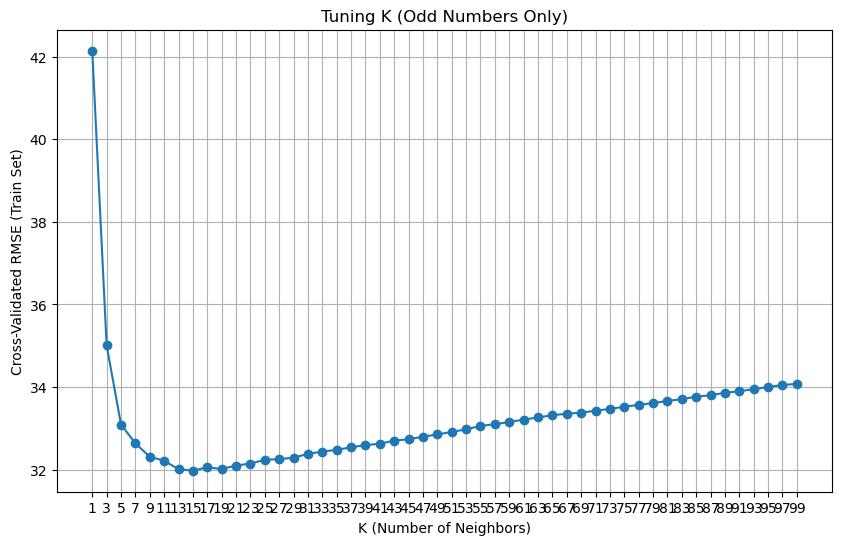

Best K: 15


In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
import numpy as np
pol_with_coord_clean = pol_with_coord.dropna().copy()
scaler = StandardScaler()
scaled = scaler.fit_transform(pol_with_coord_clean[  ["lat", "lng"]])
pol_with_coord_clean[["lat_scaled", "lng_scaled"]] = scaled
pol_with_coord_clean

X = pol_with_coord_clean[["lat_scaled", "lng_scaled"]]

y = pol_with_coord_clean["aqi_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


k_values = list(range(1, 100,2))
rmse_scores = []


for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    neg_mse = cross_val_score(knn, X_train, y_train, cv=10, scoring="neg_mean_squared_error")
    rmse = np.mean(np.sqrt(-neg_mse))
    rmse_scores.append(rmse)
    
plt.figure(figsize=(10, 6))
plt.plot(k_values, rmse_scores, marker='o')
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross-Validated RMSE (Train Set)")
plt.title("Tuning K (Odd Numbers Only)")
plt.grid(True)
plt.xticks(k_values)
plt.show()
best_k = k_values[np.argmin(rmse_scores)]
print("Best K: " + str(best_k))


In [ ]:
from sklearn.metrics import root_mean_squared_error
# Best K from CV
model_k15 = KNeighborsRegressor(n_neighbors=15)
model_k15.fit(X_train, y_train)
rmse_k15 = root_mean_squared_error(y_test, model_k15.predict(X_test)) 
print(f"Test RMSE @ K=15 (best from CV): {rmse_k15:.2f}")

Test RMSE @ K=15 (best from CV): 31.55


<Axes: xlabel='aqi_value', ylabel='Count'>

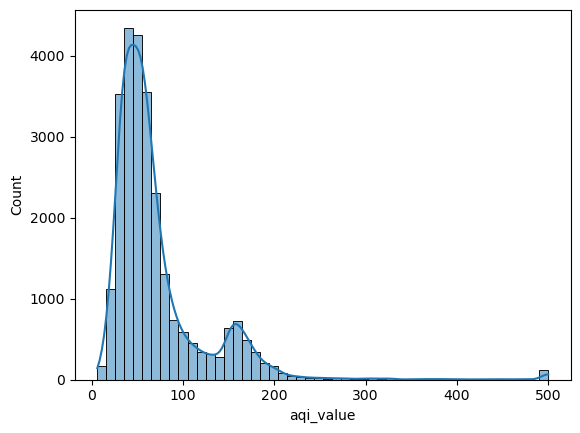

In [27]:
import seaborn as sns
sns.histplot(df["aqi_value"], bins=50, kde=True)

Best K (with clipping): 29
Best K (MAE): 21


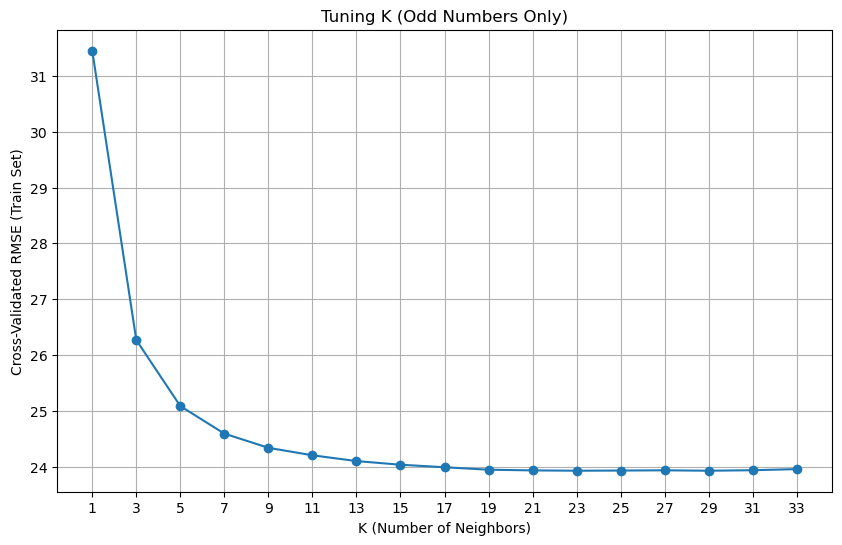

RMSE (clipped): 23.63
MAE  (clipped): 16.00


In [33]:

from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error

y_train_clipped = y_train.clip(upper=200)
y_test_clipped = y_test.clip(upper=200)


k_values = list(range(1, 35, 2))
rmse_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    neg_mse = cross_val_score(knn, X_train, y_train_clipped, cv=10, scoring="neg_mean_squared_error")
    rmse = np.mean(np.sqrt(-neg_mse))
    rmse_scores.append(rmse)
best_k = k_values[np.argmin(rmse_scores)]
print(f"Best K (with clipping): {best_k}")


# k values for MAE
mae_scores = []
k_values_m = list(range(1, 35, 2))  # or narrower, like range(1, 101, 2)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
for k in k_values_m:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    scores = cross_val_score(knn, X_train, y_train_clipped, cv=10, scoring=mae_scorer, n_jobs=-1)
    mae = -np.mean(scores)
    mae_scores.append(mae)

best_k_mae = k_values[np.argmin(mae_scores)]
print(f"Best K (MAE): {best_k_mae}")




plt.figure(figsize=(10, 6))
plt.plot(k_values, rmse_scores, marker='o')
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross-Validated RMSE (Train Set)")
plt.title("Tuning K (Odd Numbers Only)")
plt.grid(True)
plt.xticks(k_values)
plt.show()
best_k = k_values[np.argmin(rmse_scores)]


model = KNeighborsRegressor(n_neighbors=best_k, weights='distance')
model.fit(X_train, y_train_clipped)  

y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test_clipped, y_pred)
mae = mean_absolute_error(y_test_clipped, y_pred)





print(f"RMSE (clipped): {rmse:.2f}")
print(f"MAE  (clipped): {mae:.2f}")



In [ ]:
# Testing with Best K for optimal MAE

model = KNeighborsRegressor(n_neighbors=best_k_mae, weights='distance')
model.fit(X_train, y_train_clipped)  

y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test_clipped, y_pred)
mae = mean_absolute_error(y_test_clipped, y_pred)

print(f"RMSE (clipped): {rmse:.2f}")
print(f"MAE  (clipped): {mae:.2f}")

# Very Slight differences in RMSE and MAE, but MAE is slightly better.


RMSE (clipped): 23.67
MAE  (clipped): 15.97
